![logo](./img/TheBridge_RL.png)

# Introducción a los entornos de prueba de aprendizaje por refuerzo (el Gym) (II)

Implementación actualizada a Gymnasium. Se respetan `terminated` y `truncated`, se fijan semillas y se cierran los entornos. Taxi utiliza la versión disponible de Gymnasium (v4 en el entorno validado).

## Contenidos

* [Antes de empezar: Animaciones con Matplotlib](#Antes-de-empezar:-Animaciones-con-Matplotlib)  
* [Ciclo 'ejemplo' de Aprendizaje por Refuerzo](#Ciclo-'ejemplo'-de-Aprendizaje-por-Refuerzo)  


### Antes de empezar: Animaciones con Matplotlib  
[al indice](#Contenidos)  


En la sesión anterior vimos como mostrar un estado de un entorno del Gym de OpenAI, pero lo que realmente nos interesa es ver la animación completa de una serie de pasos o acciones (un step)

Para ello vamos a emplear las animaciones de la librería matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from IPython.display import display
from rl_support import animate,episode,evaluate,train_taxi,load_or_train,cache_path,TAXI_ID
SEED=42

Primero importamos los módulos de la librería que nos interesan (animation y pyplot) y después ajustamos algunos parámetros de configuración. El importante es el úlitmo en el que le indicamos a pyplot que utilizaremos animaciones sobre un componente interno javascript.

Ahora preparamos algunas funciones para que construyan la animacion dada una coleción de "pantallazos" (frames) proporcionados por el entorno de gym al invocar el método render (env.render())

In [2]:
plot_animation=animate

Para ver cómo funciona, la aplicamos al último ejemplo de la sesión anterior

In [3]:
env=gym.make('MountainCar-v0',render_mode='rgb_array');obs,info=env.reset(seed=SEED)
frames=[env.render()]
for _ in range(50):
 obs,reward,terminated,truncated,info=env.step(0)
 frames.append(env.render())
 if terminated or truncated:break
env.close()

In [4]:
display(plot_animation(frames[::2]))

### Ciclo 'ejemplo' de Aprendizaje por Refuerzo  
[al indice](#Contenidos)  


Recordamos como era un ciclo o proceso de Aprendizaje por refuerzo:

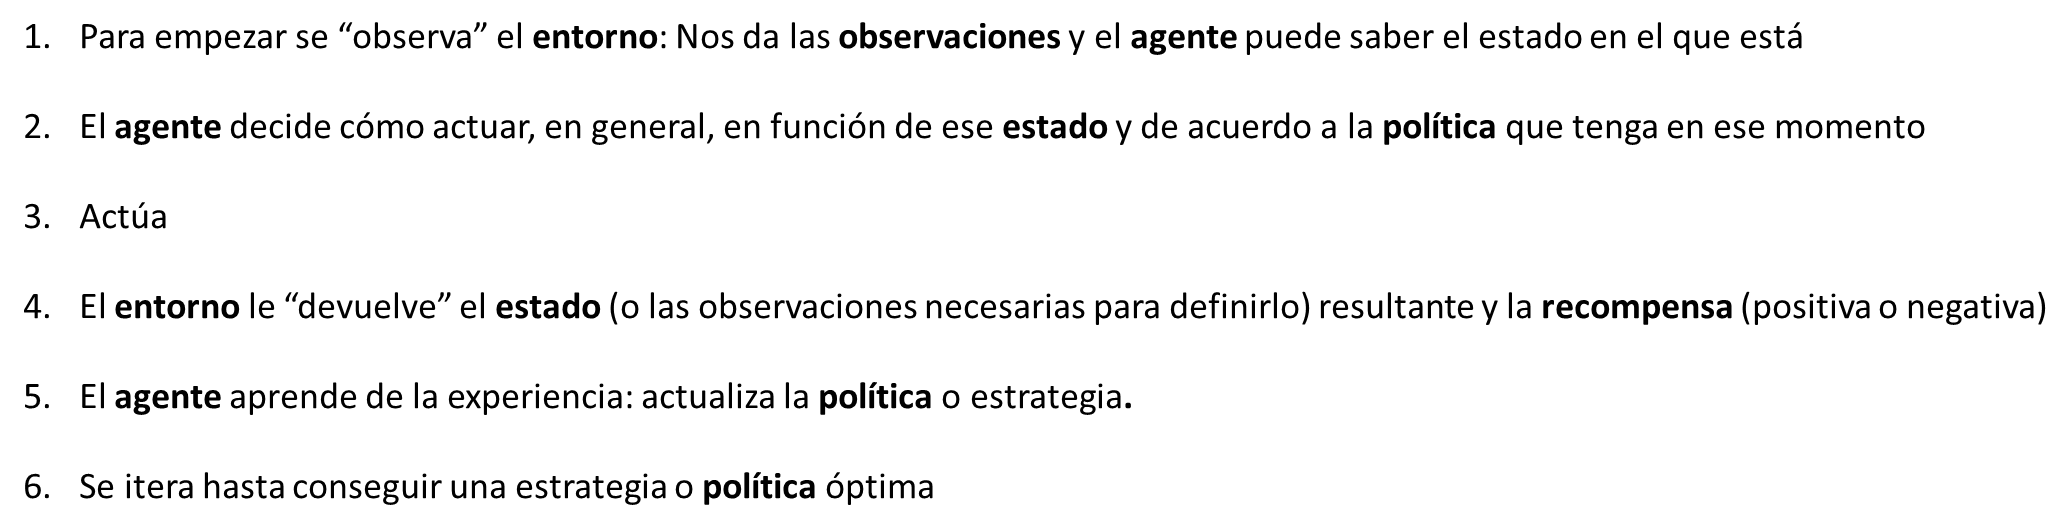

Antes de empezar necesitaremos una política/policy que nos diga que acción tomar en cada momento y una función fictica que actualice (que aprenda) esa oolítica/policy en función de las recompensas. Lo demás lo podemos implementar usando las funciones y métodos del entorno

In [5]:
def policy(obs):return 2 if obs[1]>=0 else 0
def update_policy(*args):
 # Política estática: no hay actualización de parámetros.
 pass

Ahora, ya podemos crear el ciclo

In [6]:
env=gym.make('MountainCar-v0',render_mode='rgb_array');obs,info=env.reset(seed=SEED)
frames=[env.render()];total=0
for step in range(200):
 action=policy(obs);new,reward,terminated,truncated,info=env.step(action)
 update_policy(obs,action,reward,new);obs=new;total+=reward;frames.append(env.render())
 if terminated or truncated:break
print('Pasos',step+1,'Recompensa',total,'Objetivo alcanzado',terminated);env.close()

Pasos 121 Recompensa -121.0 Objetivo alcanzado True


Genial, no hemos necesitado siquiera que aprendiese, con la política inicial ha sido suficiente para conseguir el objetivo, pero eso no quiere decir que no haya una política mejor (es decir que obtenga un castigo menor). Si hubieramos implementado update_policy es posible que hubieramos encontrado una mejor

En las siguientes sesiones vamos a ayudar a aprender a un coche a conducir por sí solo y recoger pasajeros, pero esta vez aprendiendo la política o estrategia de acción.

In [7]:
display(animate(frames[::3]))

## Ahora tú

Cambia la política de nuestra vagoneta o bien carga otro entorno (CarPole por ejemplo), busca documentación y crea una poítica para intentar resolver, a este tipo de política sin actualizaciones se les llama también políticas estáticas.

Ya que tienes entrada gratis en este GYM no dejes de usarlo!!!


**IMPORTANTE**: No todos los entornos se pueden mostrar (renderizar) de forma directa en todos los sistemas operativos, tendrás que mirarlo con un poquito de cuidado

**CONSEJO**: Descargate este notebook y juega con él en tu ordenador, el entorno remoto está restringido en su capacidad para las sesiones online

In [8]:
env=gym.make('CartPole-v1',render_mode='rgb_array');obs,info=env.reset(seed=SEED)
frames=[];total=0
for step in range(500):
 action=int(obs[2]+.25*obs[3]>0)
 obs,reward,terminated,truncated,info=env.step(action);total+=reward
 if step%8==0:frames.append(env.render())
 if terminated or truncated:break
env.close();print('Recompensa CartPole con política estática:',total);display(animate(frames))

Recompensa CartPole con política estática: 500.0
